In [101]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW, Adam

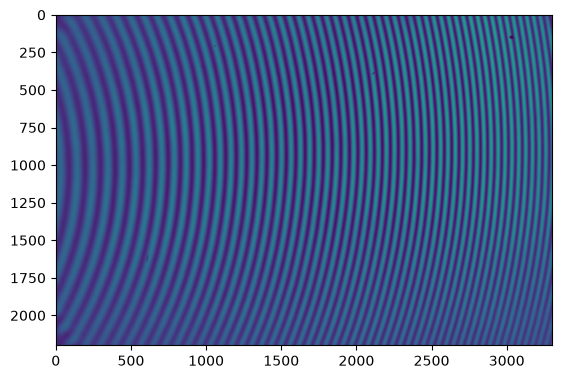

In [100]:
# Read data
data = np.load("../../data/both_arms_piezo_no_delay_20260902_142933.npz")
stack = data["stack"][0]

plt.imshow(stack[0])

Converged: True
Iteration: 24
RMSE: 64.37635803222656
R: 0.05721249058842659, R2: 0.07871923595666885


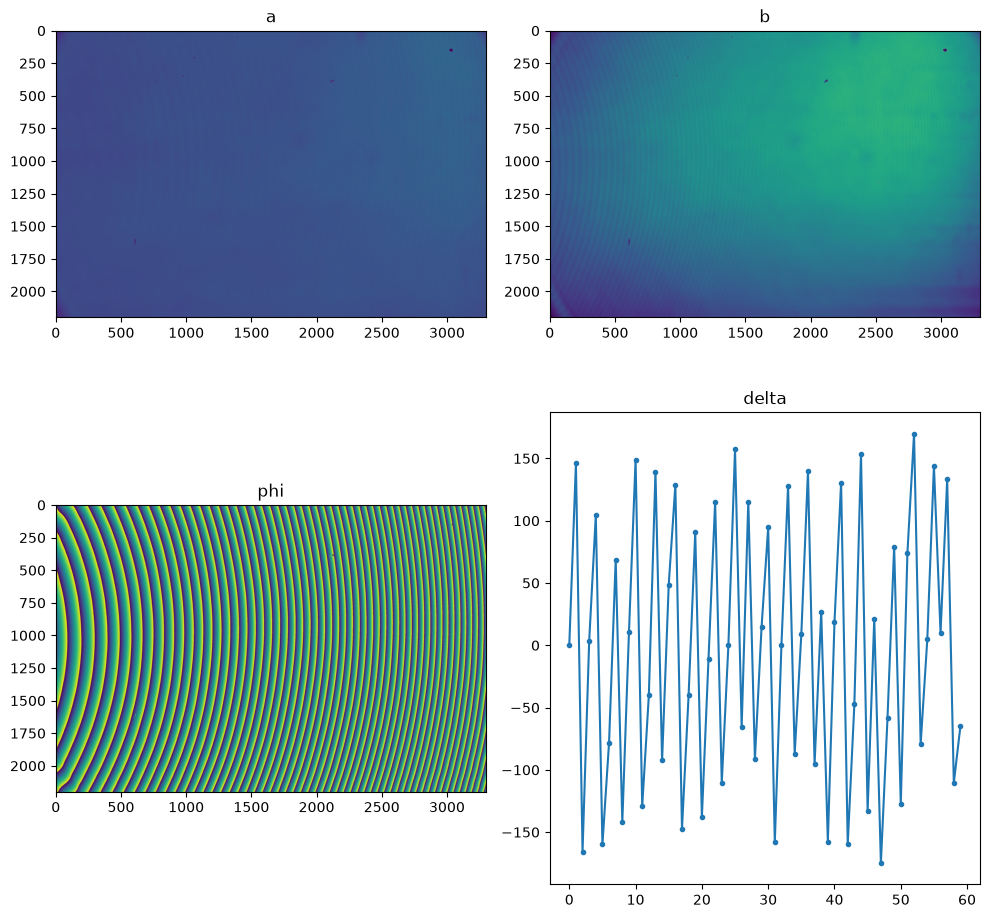

In [276]:
from phase.backend import wrap

# AIA test
iters = 50
dtype = np.float32
tol=1e-6


N = 60 # frames to take out of 60

probe_stack = stack[:N, :, :]
In = probe_stack.reshape(N, -1).astype(dtype) # flattent spatial dim
_, H, W = probe_stack.shape

# 1. Sample delta
delta = np.arange(N) * 2 * np.pi / N # uniform
#delta = np.arange(N) * np.pi/2 # step
delta = delta.astype(dtype)

# 2. Init UV vector
UV = np.zeros((In.shape[-1], 3), dtype)
UV[:,0] = 1.0

u = v = a = None
A = None
converged = False
it = 0

for it in range(iters):
    # pixel step: I_n = a + g_n*(u cosδ_n + v sinδ_n),  u=b cosφ, v=-b sinφ
    c, s = np.cos(delta), np.sin(delta)
    A = np.column_stack([np.ones(N), c, s])                # (N,3) float64
    X = np.linalg.pinv(A).astype(dtype) @ In                   # (3,P)
    a, u, v = X[0], X[1], X[2]

    # frame step: fit [alpha_n, Pn, Qn] against the fixed u,v patterns
    UV[:, 1] = u
    UV[:, 2] = v
    BtB = (UV.T @ UV).astype(dtype)                          # (3,3)
    IB = (In @ UV).astype(dtype)                              # (N,3)
    x = np.linalg.solve(BtB, IB.T)                                # (3,N)
    Pn, Qn = x[1], x[2]
    new_delta = np.arctan2(Qn, Pn)

    new_delta = new_delta - new_delta[0]                          # pin phase origin
    step = float(np.abs(wrap(new_delta - delta)).max())
    delta = new_delta
    if step < tol:
        converged = True
        break
    
phi = np.arctan2(-v, u).reshape(H, W)
u64, v64 = u.astype(dtype), v.astype(dtype)
b   = np.sqrt(u64**2 + v64**2).reshape(H, W)
a_map = a.reshape(H, W)

In_t = a_map[None,:,:] + b[None,:,:]*np.cos(phi[None,:,:] + new_delta[:,None,None])
error = np.sqrt(np.mean((probe_stack - In_t)**2))

print(f"Converged: {converged}")
print(f"Iteration: {it}")
print(f"RMSE: {error}")

R  = np.abs(np.exp(1j*new_delta).mean())
R2 = np.abs(np.exp(2j*new_delta).mean())
print(f"R: {R}, R2: {R2}")

    
plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.title("a")
plt.imshow(a_map)

plt.subplot(222)
plt.title("b")
plt.imshow(b)

plt.subplot(223)
plt.title("phi")
plt.imshow(phi)

plt.subplot(224)
plt.title("delta")
plt.plot(new_delta/np.pi*180, ".-")

plt.tight_layout()

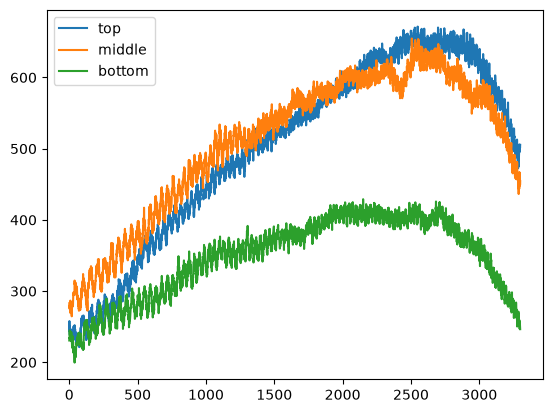

In [277]:
plt.plot(b[250], label="top")
plt.plot(b[1000], label="middle")
plt.plot(b[1750], label="bottom")
plt.legend()

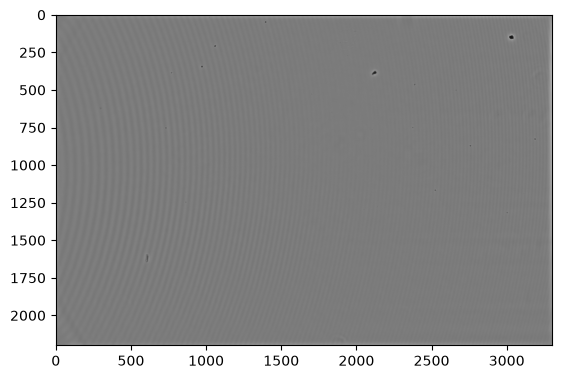

In [278]:
def gauss1d(sig, truncate=4):
    r = int(truncate*sig+0.5)
    x = np.arange(-r, r+1)
    k = np.exp(-x**2/(2*sig**2)); return k/k.sum()

def blur(img, sig):
    k = gauss1d(sig)
    out = np.apply_along_axis(lambda m: np.convolve(m, k, 'same'), 0, img)
    out = np.apply_along_axis(lambda m: np.convolve(m, k, 'same'), 1, out)
    return out

sigma = 15
b_env = blur(b, sigma)
a_env = blur(a_map, sigma)
b_ripple = b - b_env
a_ripple = a_map - a_env
plt.imshow(b_ripple, cmap='grey')


(600.0, 900.0)

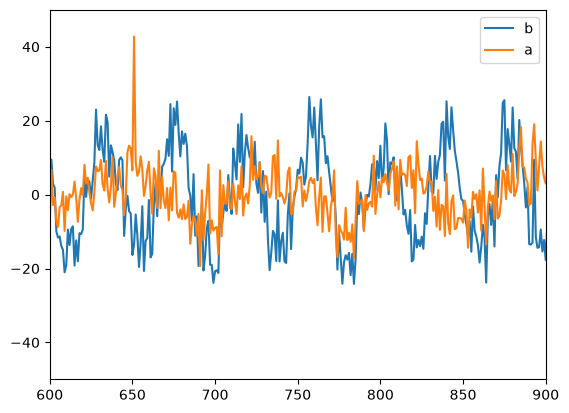

In [291]:
# plt.plot(b_ripple[250], label="top")
plt.plot(b_ripple[1000], label="b")
plt.plot(a_ripple[1000], label="a")
# plt.plot(b_ripple[1750], label="bottom")
plt.legend()
plt.ylim([-50, 50])
plt.xlim([600, 900])

In [280]:
xa = a_ripple[1000, 2500:3000]
xb = b_ripple[1000, 2500:3000]
fa = np.abs(np.fft.rfft(xa-xa.mean())); fb = np.abs(np.fft.rfft(xb-xb.mean()))
print("a peak bin:", fa.argmax(), " b peak bin:", fb.argmax())

a peak bin: 10  b peak bin: 21


In [281]:
import numpy as np

# --- ROI on the glass: pick a region with clear fringes ---
y0, y1 = 800, 1312      # 512 rows
x0, x1 = 1400, 1912     # 512 cols
roi = stack[:, y0:y1, x0:x1].astype(np.float64)     # (N,h,w)
N, h, w = roi.shape

# --- window to suppress spectral leakage from DC / conjugate lobe ---
win = np.outer(np.hanning(h), np.hanning(w))
roi_w = (roi - roi.mean(axis=(1,2), keepdims=True)) * win

# --- FFT all frames, find the STATIC carrier bin from average spectrum ---
F = np.fft.fft2(roi_w, axes=(1,2))          # (N,h,w) complex
P = np.abs(F).mean(0)                        # avg magnitude over frames
P[:4,:4]=0; P[-4:,:4]=0; P[:4,-4:]=0; P[-4:,-4:]=0   # kill DC neighborhood
P[0,:]=0; P[:,0]=0
ky, kx = np.unravel_index(np.argmax(P), P.shape)
print("carrier bin (ky,kx):", ky, kx)

# --- delta_n = phase of carrier bin, relative to frame 0 (wrapped) ---
C = F[:, ky, kx]                             # (N,) complex; arg = delta_n + const
delta_spatial = np.angle(C * np.conj(C[0]))  # removes static arg(G) and frame-0 offset

R  = np.abs(np.exp(1j*delta_spatial).mean())
R2 = np.abs(np.exp(2j*delta_spatial).mean())
print("R:", R, "R2:", R2)

carrier bin (ky,kx): 1 8
R: 0.06837932847781698 R2: 0.09888292449101943


0.23730256406867067
[5.30009862e-16 1.83051042e+00 3.27067341e+00 6.09867934e+00
 2.11030714e+00 7.29647552e-01 4.46401795e+00 1.27132824e+01
 6.00598818e+00 4.19296893e+00 1.99741398e+00 1.31846952e+00
 4.80023952e+00 3.01472811e+00 4.74730508e+00 3.69720940e+00
 1.96581807e-01 1.18913995e+01 1.10933463e+01 8.31083101e+00
 9.99558425e+00 1.35964354e+01 2.47651792e+00 5.95411202e+00
 7.19504767e+00 4.43070065e+00 2.47769665e+00 5.32226025e+00
 5.77797809e+00 4.48239534e+00 4.00064131e+00 9.60514581e+00
 2.97737473e+00 5.24978080e+00 8.89018366e-01 3.38103994e+00
 2.32504773e+00 6.52883039e+00 1.07147817e+01 8.98316445e-01
 2.34179573e+00 1.87491313e+00 7.23343644e+00 1.19043271e+01
 3.84970783e+00 1.14278150e+01 2.08478373e+00 5.09966354e-01
 2.81830803e+00 2.28185268e-01 1.63930784e+00 4.86449817e+00
 2.54472128e+00 3.09321098e+00 7.33645228e+00 1.03060310e+01
 6.89782941e+00 7.05857080e+00 6.89509596e+00 6.12183933e+00]


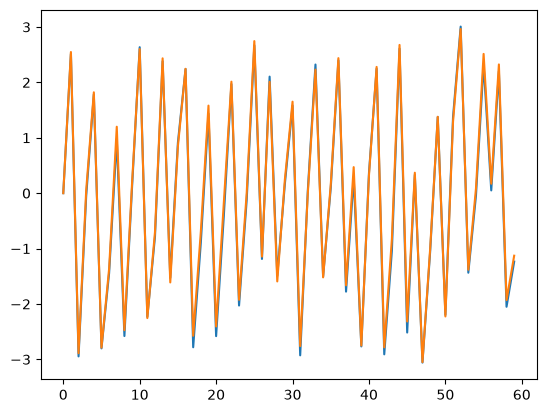

In [284]:
plt.plot(delta_spatial)
plt.plot(delta)

print(max(delta - delta_spatial))

d = np.abs(wrap(delta - delta_spatial))
print(np.rad2deg(d))          # per-frame error in degrees

In [286]:
# reconstruct b with FFT deltas instead of AIA deltas
A = np.column_stack([np.ones(N), np.cos(delta_spatial), np.sin(delta_spatial)])
_,u,v = np.linalg.pinv(A) @ In
b_fft = np.sqrt(u**2+v**2).reshape(H,W)
# compare ripple
c = slice(100, -100)
print("AIA b ripple std:", b_ripple[c,c].std())
print("FFT b ripple std:", (b_fft - blur(b_fft,15))[c,c].std())

AIA b ripple std: 10.979488279789809
FFT b ripple std: 11.014609977605703


N: 10  converged: True  it: 21  RMSE: 44.026
  R: 0.0561  R2: 0.3046   ->  R_w: 3.84e-08  R2_w: 5.23e-08


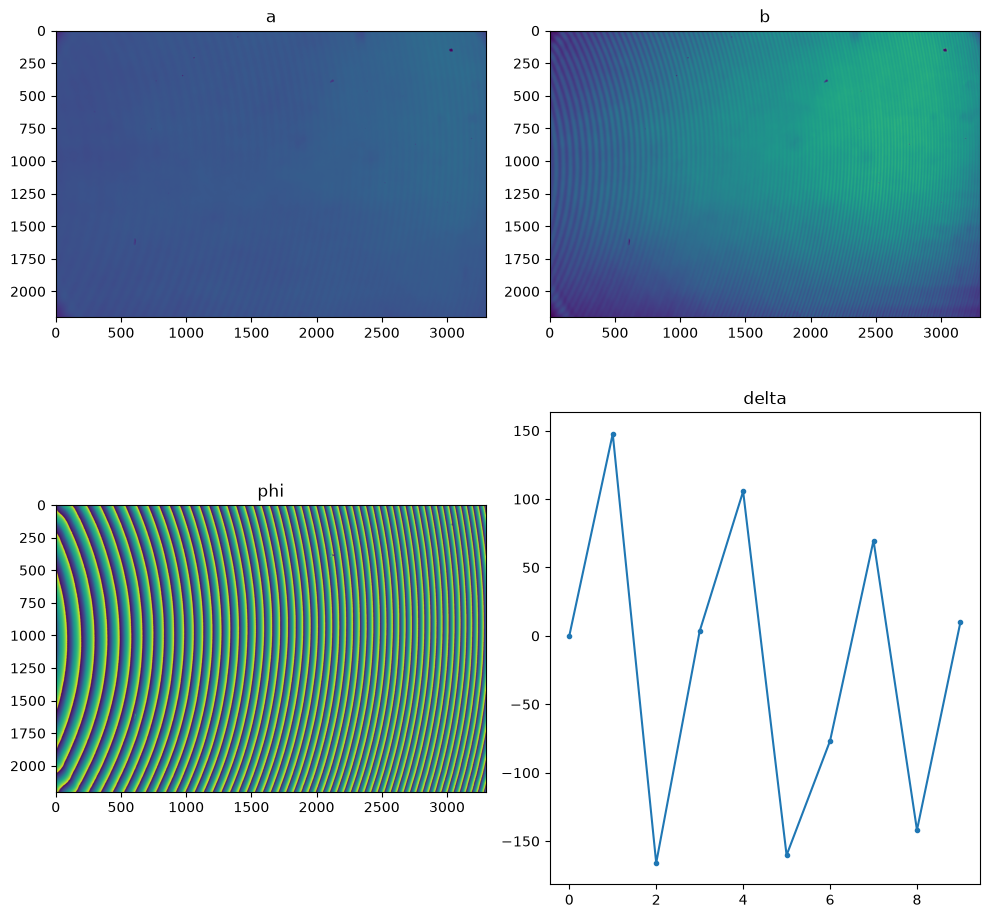

In [190]:
from phase.backend import wrap

# AIA test + weighted refit
iters = 50
dtype = np.float32
tol = 1e-4

N=10
probe_stack = stack[:N, :, :]
In = probe_stack.reshape(N, -1).astype(dtype)   # flatten spatial dim
_, H, W = probe_stack.shape

# 1. Sample delta
delta = np.arange(N) * 2 * np.pi / N
delta = delta.astype(dtype)

# 2. Init UV vector
UV = np.zeros((In.shape[-1], 3), dtype)
UV[:, 0] = 1.0

u = v = a = None
A = None
converged = False
it = 0

for it in range(iters):
    # pixel step
    c, s = np.cos(delta), np.sin(delta)
    A = np.column_stack([np.ones(N), c, s])                 # (N,3)
    X = np.linalg.pinv(A).astype(dtype) @ In                # (3,P)
    a, u, v = X[0], X[1], X[2]

    # frame step
    UV[:, 1] = u
    UV[:, 2] = v
    BtB = (UV.T @ UV).astype(dtype)
    IB  = (In @ UV).astype(dtype)
    x = np.linalg.solve(BtB, IB.T)
    Pn, Qn = x[1], x[2]
    new_delta = np.arctan2(Qn, Pn)

    new_delta = new_delta - new_delta[0]                    # pin phase origin
    step = float(np.abs(wrap(new_delta - delta)).max())
    delta = new_delta
    if step < tol:
        converged = True
        break

# ---- weighted refit: null R and R2 in delta-space ----
d   = delta
C   = np.stack([np.ones_like(d), np.cos(d), np.sin(d),
                np.cos(2*d), np.sin(2*d)])                  # (5,N)
rhs = np.array([1., 0., 0., 0., 0.], dtype)
wts = (C.T @ np.linalg.solve(C @ C.T, rhs)).astype(dtype)   # (N,)

# weighted pixel solve: AᵀWA = diag(1, ½, ½) by construction
AtW = A.T * wts                                             # (3,N)
Xw  = AtW @ In                                              # (3,P)
Xw[1] *= 2; Xw[2] *= 2                                      # undo ½ on u,v
a, u, v = Xw[0], Xw[1], Xw[2]

# ---- maps (same outputs as before) ----
phiw   = np.arctan2(-v, u).reshape(H, W)
bw     = np.sqrt(u**2 + v**2).reshape(H, W)
aw_map = a.reshape(H, W)

In_t  = aw_map[None, :, :] + bw[None, :, :] * np.cos(phiw[None, :, :] + d[:, None, None])
error = np.sqrt(np.mean((probe_stack - In_t) ** 2))

R   = np.abs(np.exp(1j*d).mean())
R2  = np.abs(np.exp(2j*d).mean())
R_w = np.abs((wts*np.exp(1j*d)).sum())
R2_w= np.abs((wts*np.exp(2j*d)).sum())

print(f"N: {N}  converged: {converged}  it: {it}  RMSE: {error:.3f}")
print(f"  R: {R:.4f}  R2: {R2:.4f}   ->  R_w: {R_w:.2e}  R2_w: {R2_w:.2e}")

plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.title("a")
plt.imshow(aw_map)

plt.subplot(222)
plt.title("b")
plt.imshow(bw)

plt.subplot(223)
plt.title("phi")
plt.imshow(phiw)

plt.subplot(224)
plt.title("delta")
plt.plot(d/np.pi*180, ".-")

plt.tight_layout()

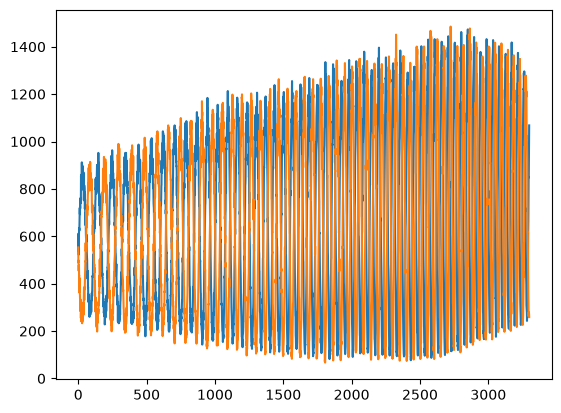

In [211]:
plt.plot(stack[0, 1000])
plt.plot(stack[17, 1000])

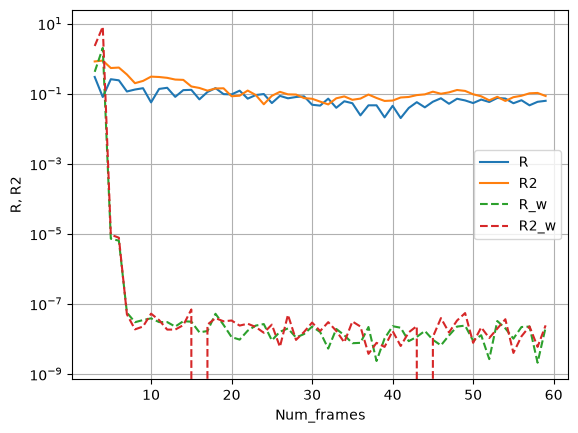

In [176]:
plt.plot(num_frame, R_list,  label="R")
plt.plot(num_frame, R2_list, label="R2")
plt.plot(num_frame, Rw_list,  '--', label="R_w")
plt.plot(num_frame, R2w_list, '--', label="R2_w")
plt.xlabel("Num_frames"); plt.ylabel("R, R2"); plt.legend(); plt.grid(True)
plt.yscale('log')

Loss: 258.76873779296875
Loss: 194.70643615722656
Loss: 99.02875518798828
Loss: 56.334434509277344
Loss: 47.09359359741211
Loss: 43.67827224731445
Loss: 40.507144927978516
Loss: 40.241703033447266
Loss: 39.885955810546875
Loss: 39.91740798950195
Loss: 39.85643768310547
Loss: 39.85178756713867
Loss: 39.84368133544922
Loss: 39.84291458129883
Loss: 39.842594146728516


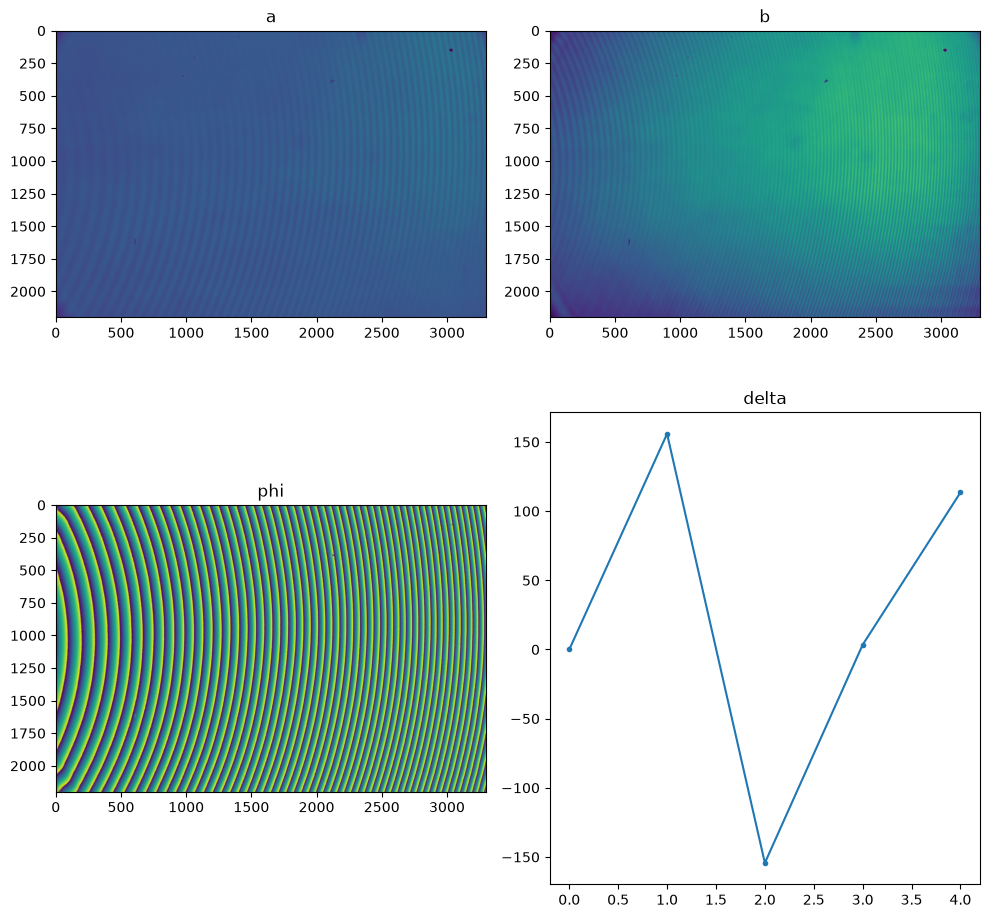

In [142]:
# Grad base approach
iters = 150
dtype = torch.float32
lr = 0.05

N = 5
probe = torch.from_numpy(stack[:N]).to(dtype=dtype)      # (N,H,W)
_, H, W = probe.shape
In = probe.reshape(N, -1)                                 # (N,P)
ones = torch.ones(N, dtype=dtype)

delta = torch.nn.Parameter((torch.arange(N) * 2*np.pi / N).to(dtype=dtype))
opt = Adam([delta], lr=lr)

for it in range(iters):
    opt.zero_grad()
    A = torch.column_stack([ones, torch.cos(delta), torch.sin(delta)])  # (N,3)
    X = torch.linalg.pinv(A) @ In                                       # (3,P), pinv = κ-safe
    loss = torch.mean((In - A @ X)**2)                                  # recon = A@X
    loss.backward()
    opt.step()
    with torch.no_grad(): 
        delta -= delta[0].clone()          # anchor δ[0]=0# wrap to (-π,π], periodic ⇒ safe
        delta.copy_(torch.atan2(torch.sin(delta), torch.cos(delta)))
    if it % 10 == 0:
        print(f"Loss: {torch.sqrt(loss.detach())}")

# params for display only (detached)
with torch.no_grad():
    A = torch.column_stack([ones, torch.cos(delta), torch.sin(delta)])
    a, u, v = torch.linalg.pinv(A) @ In
    a_img   = a.reshape(H, W)
    b_img   = torch.sqrt(u**2 + v**2).reshape(H, W)
    phi_img = torch.atan2(-v, u).reshape(H, W)

plt.figure(figsize=(10, 10))
plt.subplot(221); plt.title("a");     plt.imshow(a_img)
plt.subplot(222); plt.title("b");     plt.imshow(b_img)
plt.subplot(223); plt.title("phi");   plt.imshow(phi_img)
plt.subplot(224); plt.title("delta"); plt.plot(delta.detach()/np.pi*180, ".-")
plt.tight_layout()

R: 0.12790414690971375, R2: 0.1596350520849228


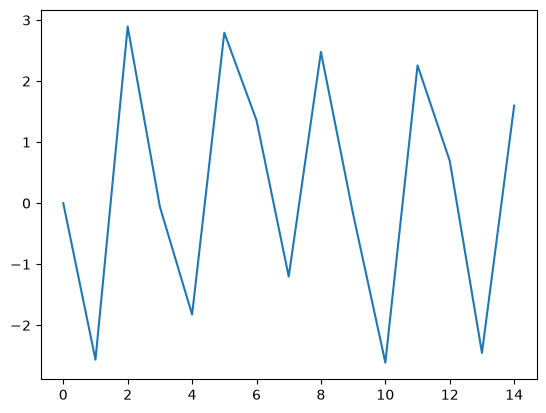

In [154]:
plt.plot(new_delta)

R  = np.abs(np.exp(1j*new_delta).mean())
R2 = np.abs(np.exp(2j*new_delta).mean())
print(f"R: {R}, R2: {R2}")

In [148]:
new_delta

array([ 0.        ,  2.6034002 , -2.8962874 ,  0.05526681,  1.8783729 ],
      dtype=float32)